In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sn

I0000 00:00:1776607218.166623   12104 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776607218.738095   12104 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776607221.511433   12104 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
image_size=256
batch_size=32

In [3]:
dataset= tf.keras.preprocessing.image_dataset_from_directory(
    "/home/david/Documents/final_year project/potato-dis/training/PlantVillage",
    shuffle=True,
    image_size=(image_size,image_size),
    batch_size= batch_size
)

Found 2152 files belonging to 3 classes.


E0000 00:00:1776607223.345420   12104 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
class_name=dataset.class_names
class_name

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

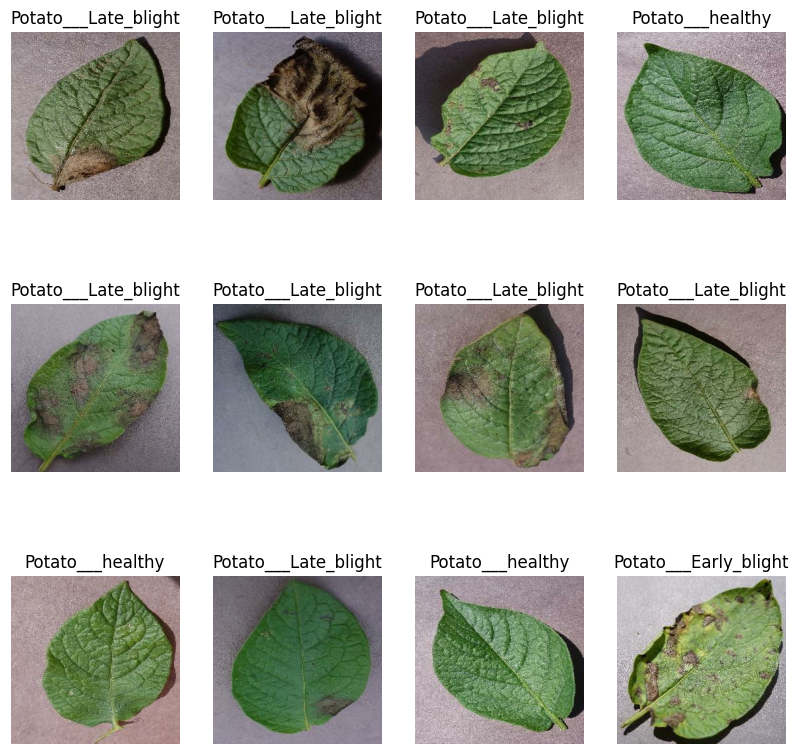

In [5]:
plt.figure(figsize=(10,10))
for img_batch,lable_batch in dataset.take(1):
      for i in range(12):
          ax=plt.subplot(3,4,i+1)
          plt.imshow(img_batch[i].numpy().astype("uint8"))
          plt.title(class_name[lable_batch[i]])
          plt.axis("off")

In [6]:
def get_dataset_partitions_tf(ds,train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    ds_size= len(ds)
    if shuffle:
        ds=ds.shuffle(shuffle_size, seed=12)
    train_size= int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds= ds.skip(train_size).take(val_size)
    test_ds= ds.skip(train_size).skip(val_size)
    return train_ds, val_ds, test_ds

In [7]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [8]:
len(train_ds), len(test_ds), len(val_ds)

(54, 8, 6)

In [9]:
train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds= val_ds.cache().shuffle(1000).prefetch(buffer_size =tf.data.AUTOTUNE)
test_ds= test_ds.cache().shuffle(1000).prefetch(buffer_size= tf.data.AUTOTUNE)

In [10]:
from tensorflow.keras import layers
resize_and_rescale_arrg= tf.keras.Sequential([
    layers.Resizing(image_size,image_size),
    layers.Rescaling(1.0/255),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)])

In [11]:
input_shape = (batch_size, image_size, image_size, 3)
model = models.Sequential([
    resize_and_rescale_arrg,
    layers.Conv2D(32,(3,3), activation = 'relu', input_shape = input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size =(3,3),activation ='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size = (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation = 'relu'),




    
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3,activation = 'softmax'),
])
model.build(input_shape = input_shape)

/home/david/py/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer = 'adam',
             loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
             metrics = ['accuracy'])

In [14]:
history = model.fit(
    train_ds,
    epochs=50,
    batch_size = batch_size,
    verbose = 1,
    validation_data = val_ds
)

Epoch 1/50


W0000 00:00:1776607228.111555   12182 cpu_allocator_impl.cc:82] Allocation of 264257536 exceeds 10% of free system memory.
W0000 00:00:1776607229.018543   12177 cpu_allocator_impl.cc:82] Allocation of 264257536 exceeds 10% of free system memory.


 1/54 ━━━━━━━━━━━━━━━━━━━━ 4:09 5s/step - accuracy: 0.1250 - loss: 1.1080

W0000 00:00:1776607229.495866   12178 cpu_allocator_impl.cc:82] Allocation of 264257536 exceeds 10% of free system memory.
W0000 00:00:1776607230.147849   12177 cpu_allocator_impl.cc:82] Allocation of 264257536 exceeds 10% of free system memory.


 2/54 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.2266 - loss: 1.1015 

W0000 00:00:1776607230.478390   12181 cpu_allocator_impl.cc:82] Allocation of 264257536 exceeds 10% of free system memory.


54/54 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.4641 - loss: 0.9301 - val_accuracy: 0.5833 - val_loss: 0.8901
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.5745 - loss: 0.8614 - val_accuracy: 0.7240 - val_loss: 0.6935
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.7350 - loss: 0.6167 - val_accuracy: 0.8438 - val_loss: 0.4424
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.8200 - loss: 0.4402 - val_accuracy: 0.8385 - val_loss: 0.4439
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.8633 - loss: 0.3570 - val_accuracy: 0.8021 - val_loss: 0.4762
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.8844 - loss: 0.2839 - val_accuracy: 0.9062 - val_loss: 0.2675
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.8938 - loss: 0.2661 - val_accuracy: 0.9219 - val_loss: 0.2074
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.9102 - loss: 0.2374 - val_accuracy: 0.9375 - val_loss: 0.1846

In [15]:
score= model.evaluate(test_ds)
score

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step - accuracy: 0.9922 - loss: 0.0251


[0.02509317919611931, 0.9921875]

In [16]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [17]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [18]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

Text(0.5, 1.0, 'Training and Validation Loss')

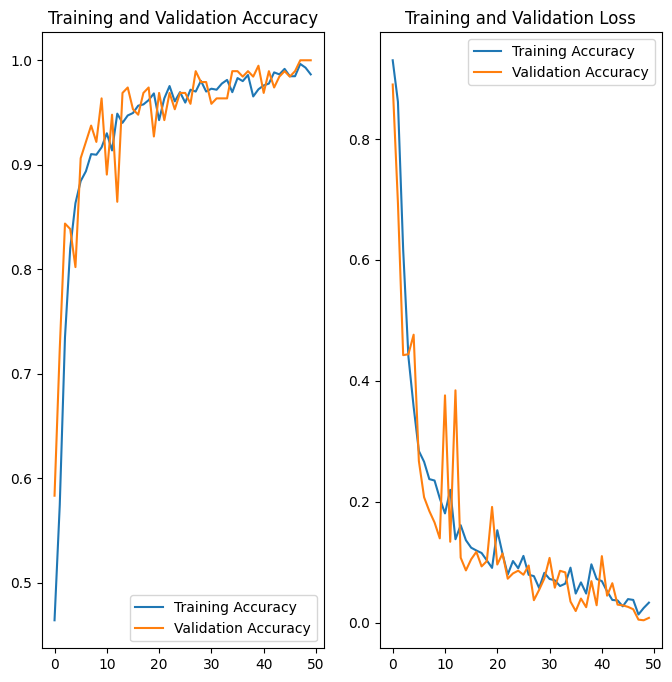

In [19]:
plt.figure(figsize =(8,8))
plt.subplot(1,2,1)
plt.plot(range(50), acc, label='Training Accuracy')
plt.plot(range(50), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(range(50), loss, label='Training Accuracy')
plt.plot(range(50), val_loss, label='Validation Accuracy')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

first image to predict
actual lable: Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
Predicted label: Potato___Early_blight


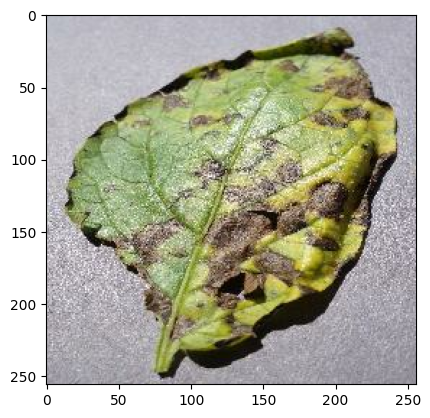

In [23]:
for images_batch, labels_batch in test_ds.take(1):
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("actual lable:",class_name[first_label])
    batch_prediction = model.predict(images_batch)
    print("Predicted label:",class_name[np.argmax(batch_prediction[0])])

In [21]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []
for images, labels in dataset:
    preds = model.predict(images)
    y_true.extend(labels.numpy())                  
    y_pred.extend(np.argmax(preds, axis=1))        

cm = confusion_matrix(y_true, y_pred)

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
class_names = ['Potato_Early_blight', 'Potato_Late_blight', 'Potato_healthy']
print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
plt.figure(figsize=(8,6)) 
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels= class_names, yticklabels=class_names) 
plt.xlabel('Predicted Label') 
plt.ylabel('True Label') 
plt.title('Confusion Matrix') 
plt.show()